## Framework Overview  

This framework is designed to streamline the **data preprocessing pipeline** by implementing multiple algorithms for:  

- **Data Cleansing**  
- **Outlier Detection & Handling**  
- **Feature Selection**  
- **Model Selection**  

At each step, we evaluate the effectiveness of different algorithms using a **shallow Decision Tree model** and  a **KNN Model**. This allows us to determine the best preprocessing strategy based on performance.  


## Importing Packages

In [39]:
# !pip3 install jdatetime

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import jdatetime #Convert From Jalali to Datetime
from sklearn.preprocessing import LabelEncoder # Encode y column
from dateutil.parser import parse #Detect Date Columns
from sklearn.model_selection import train_test_split #Weak Model Test
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score #Weak Model Test
from sklearn.tree import DecisionTreeClassifier #Weak Model Test
from sklearn.neighbors import KNeighborsClassifier #Weak Model Test
from sklearn.impute import SimpleImputer, KNNImputer #Handle Missing
from sklearn.linear_model import LinearRegression #Handle Missing
from sklearn.experimental import enable_iterative_imputer #Handle Missing(Imported Because of API Change)
from sklearn.impute import IterativeImputer #Handle Missing
from sklearn.neighbors import LocalOutlierFactor #Tame Outlier
from sklearn.ensemble import IsolationForest #Tame Outlier
from scipy.stats import zscore #Tame Outlier
from sklearn.preprocessing import RobustScaler,MinMaxScaler,StandardScaler # Nomalization
from sklearn.feature_selection import SelectKBest,f_classif,SelectFromModel,RFE,chi2,VarianceThreshold, mutual_info_classif # Feature Selection
from sklearn.svm import LinearSVC # Feature Selection
from sklearn.ensemble import ExtraTreesClassifier # Feature Selection
from sklearn.linear_model import LogisticRegression # Feature Selection
from sklearn.model_selection import GridSearchCV #Model Training
from sklearn.neural_network import MLPClassifier #Model Training
from sklearn.svm import SVC #Model Training
from sklearn.ensemble import RandomForestClassifier #Model Training
from xgboost import XGBClassifier #Model Training
from sklearn.metrics import accuracy_score #Model Training

## Handle Date Columns

In [41]:
def is_pure_date_string(s):
    try:
        s = s.strip()
        if any(char.isalpha() for char in s):
            return False
        Sep=""
        if("/" in s):
            Sep=s.split("/")
        elif("-" in s):
            Sep=s.split("-")
        else:
            return False
        if(len(Sep)==3):
            try:
                _,_,_=map(int,Sep)
                return True
            except:
                return False
    except:
        return False

def identify_date_columns(data):
    """Detect columns where all non-null values are pure date strings."""
    date_columns = []

    for col in data.select_dtypes(include=['object', 'string']):
        non_null_values = data[col].dropna()

        if non_null_values.apply(is_pure_date_string).all():
            date_columns.append(col)

    return date_columns

def convert_jalali_column_to_datetime(col):
    converted = []
    for val in col:
        try:
            val = str(val).strip()
            parts = val.split('/')
            if len(parts) == 3:
                year, month, day = map(int, parts)
                jdate = jdatetime.date(year, month, day).togregorian()
                dt = pd.Timestamp(jdate)
            else:
                dt = pd.NaT
        except:
            dt = pd.NaT
        converted.append(dt)
    return pd.Series(converted)

def detect_calendar_type(date_str):
    """
    Detects whether a date is likely Jalali or Gregorian based on year.
    Returns 'jalali', 'gregorian', or 'unknown'.
    """
    try:
        date_str = str(date_str).strip()
        parts=""
        if("/" in date_str):
            parts = date_str.split('/')
        elif("-" in date_str):
            parts = date_str.split('/')
        if len(parts) != 3:
            return 'unknown'
        year = int(parts[0])
        if 1200 <= year <= 1500:
            return 'jalali'
        elif 1800 <= year <= 2200:
            return 'gregorian'
        else:
            return 'unknown'
    except:
        return 'unknown'

def process_date_columns(data, reference_column=None):
    """ Processes the date columns and extracts useful time-based features."""

    date_columns=identify_date_columns(data)
    if(len(date_columns)==0):
        return data
    typeCal=detect_calendar_type((data[date_columns[0]].values)[0])
    if(typeCal=="jalali"):
        for col in date_columns:
            data[col] = convert_jalali_column_to_datetime(data[col])
    else:
        for col in date_columns:
            data[col] = pd.to_datetime(data[col], errors='coerce')

    for col in date_columns:
        data[f'{col}_year'] = data[col].dt.year.astype(float)
        data[f'{col}_month'] = data[col].dt.month.astype(float)
        data[f'{col}_day'] = data[col].dt.day.astype(float)
        data[f'{col}_day_of_week'] = data[col].dt.dayofweek.astype(float)
        data[f'{col}_hour'] = data[col].dt.hour.astype(float)
        data[f'{col}_day_of_year'] = data[col].dt.dayofyear.astype(float)
        data[f'{col}_is_weekend'] = (data[col].dt.weekday >= 5).astype(float)


    if reference_column:
        for col in date_columns:
            data[f'{col}_time_diff'] = (data[reference_column] - data[col]).dt.total_seconds() / (60 * 60 * 24)

    return data.drop(columns=date_columns)

## Convert into Numeric Values

In [42]:
def ConvertToNumeric(data):
    data=process_date_columns(data)
    cols = data.columns
    num_cols = data._get_numeric_data().columns
    categorical_columns = list(set(cols) - set(num_cols))

    for column in categorical_columns:
        categories = list(data[column].dropna().astype(str).unique())
        data[column] = data[column].map(lambda x: categories.index(str(x)) if str(x) in categories else x)

    return data

## Loading Data

In [43]:
def load_data(path, y_column):
    if("csv" in path):
        data=pd.read_csv(path, na_values=[" ", "", "NA", "NaN"])
    elif("xlsx" in path):
        data=pd.read_excel(path,na_values=[" ", "", "NA", "NaN"])
    else:
        print("Format not Supported")
        return None
    threshold = 2
    valid_cols = data.columns[data.notna().sum() >= threshold]
    data = data[valid_cols]

    data=ConvertToNumeric(data)
    le = LabelEncoder()
    data[y_column] = le.fit_transform(data[y_column])
    Y=data[y_column]
    X=data.drop(columns=y_column)

    return X,Y,data

In [44]:
def VerifyNoNan(X,Y):
    print(X.isna().sum().sum(),Y.isna().sum().sum())
    print(np.isinf(X).sum().sum())
    print(X.info())
    print(X.shape)
    print(Y.shape)
    print((X.index == Y.index).all())

## Implementing Test Models

In [45]:
def train_and_evaluate(X, y, expand=False):
    """Trains multiple weak models (3x KNN and 3x Decision Tree) and evaluates them."""

    if len(y) <= 5 or len(X) <= 5:
        return 0

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    models = [
        KNeighborsClassifier(n_neighbors=3),
        KNeighborsClassifier(n_neighbors=5),
        KNeighborsClassifier(n_neighbors=7),

        DecisionTreeClassifier(max_depth=3, random_state=42),
        DecisionTreeClassifier(max_depth=5, random_state=42),
        DecisionTreeClassifier(max_depth=None, min_samples_split=10, random_state=42),

    ]

    all_scores = []

    for i, model in enumerate(models):
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        acc = accuracy_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred, average='weighted', zero_division=1)
        rec = recall_score(y_test, y_pred, average='weighted', zero_division=1)
        f1 = f1_score(y_test, y_pred, average='weighted')
        coefs_scores=[0.5,2,2,1]
        all_scores.extend([acc*coefs_scores[0], prec*coefs_scores[1], rec*coefs_scores[2], f1*coefs_scores[3]])

        if expand:
            print(f"\nModel {i+1}: {model.__class__.__name__}")
            print(f"  Accuracy: {acc:.4f}, Precision: {prec:.4f}, Recall: {rec:.4f}, F1-score: {f1:.4f}")

    weighted_score = sum(all_scores) / len(all_scores)

    return weighted_score


# Handling Missing Data

These functions help clean our dataset by handling missing values efficiently and selecting the best imputation method.

## Available Algorithms  
- **Dropping Methods:**  
  - Drop columns with null values exceeding a threshold  
  - Drop rows with missing values  

- **Statistical Imputation:**  
  - Impute with **mean** or **median**  
  - Impute with **class-specific mean** or **median**  

- **Forward & Backward Filling:**  
  - **Forward fill (ffill)**  
  - **Backward fill (bfill)**  
  - **Interpolate** missing values  

- **Model-Based Imputation:**  
  - **Model Imputation** (predict missing values using a simple model)  
  - **Iterative Model Imputation** (refines predictions iteratively)  
  - **KNN Imputation** (fills missing values based on k-nearest neighbors)  


In [46]:
def drop_rows(X, Y):
    """Drops rows with any missing values."""

    mask=X.notna().all(axis=1)
    return X[mask], Y[mask]

def impute_mean(X, Y):
    """Fills missing values with column mean while leaving non-missing values intact."""


    imputer = SimpleImputer(strategy="mean")
    X_imputed = imputer.fit_transform(X)
    X_imputed_df = pd.DataFrame(X_imputed, columns=X.columns)

    X_filled = X.copy()
    for col in X.columns:
        X_filled[col] = np.where(X[col].isna(), X_imputed_df[col], X_filled[col])

    return X_filled,Y

def impute_median(X, Y):
    """Fills missing values with column median while leaving non-missing values intact."""


    imputer = SimpleImputer(strategy="median")
    X_imputed = imputer.fit_transform(X)
    X_imputed_df = pd.DataFrame(X_imputed, columns=X.columns)

    X_filled = X.copy()
    for col in X.columns:
        X_filled[col] = np.where(X[col].isna(), X_imputed_df[col], X_filled[col])

    return X_filled,Y

def impute_class_mean(X, Y):
    """Fills missing values with the mean of each class in Y, ensuring no NaNs remain."""


    X_copy = X.copy()
    for col in X.columns:
        grouped_means = X.groupby(Y)[col].transform(lambda x: x.mean())
        X_copy[col] = X[col].fillna(grouped_means)  # Fill NaNs with class mean

        if X_copy[col].isna().sum() > 0:
            X_copy[col].fillna(X[col].mean(), inplace=True)

    return X_copy, Y

def impute_class_median(X, Y):
    """Fills missing values with the median of each class in Y."""


    X_copy = X.copy()
    for col in X.columns:
        X_copy[col] = X.groupby(Y)[col].transform(lambda x: x.fillna(x.median()))

        if X_copy[col].isna().sum() > 0:
            X_copy[col].fillna(X[col].mean(), inplace=True)
    return X_copy,Y

def ffill(X, Y):
    """Fills missing values with the previous row (forward fill) and ensures no NaNs remain."""

    X_filled = X.ffill()
    X_filled = X_filled.bfill()
    return X_filled, Y

def bfill(X, Y):
    """Fills missing values with the next row (backward fill)."""

    X_filled = X.bfill()
    X_filled = X_filled.ffill()
    return X_filled,Y

def interpolate(X, Y):
    """Interpolates missing values linearly and ensures no NaNs remain."""


    X_filled = X.interpolate(method="linear", limit_direction="both")
    return X_filled, Y



def Model_imputation(X, Y):
    """Uses a simple regression model to impute missing values."""

    X_copy = X.copy()

    for col in X_copy.columns:
        missing_mask = X_copy[col].isna()
        if missing_mask.sum() > 0:
            known_data = X_copy[~missing_mask].copy()
            known_X = known_data.drop(columns=[col])
            known_y = known_data[col]

            known_X = known_X.apply(lambda col: col.fillna(col.mean()), axis=1)

            missing_X = X_copy.loc[missing_mask].drop(columns=[col])
            missing_X = missing_X.fillna(known_X.mean())

            if len(known_X) > 0 and len(missing_X) > 0:
                model = LinearRegression()
                model.fit(known_X, known_y)
                X_copy.loc[missing_mask, col] = model.predict(missing_X)

    return X_copy, Y

def Iterative_model_Imputation(X, Y):
    """Uses iterative imputation (sklearn's IterativeImputer) to fill only null values."""


    imputer = IterativeImputer()
    X_imputed = imputer.fit_transform(X)
    X_imputed_df = pd.DataFrame(X_imputed, columns=X.columns)

    X_filled = X.copy()

    for col in X.columns:
        X_filled[col] = np.where(X[col].isna(), X_imputed_df[col], X_filled[col])

    return X_filled,Y

def KNN_Imputation(X, Y, n_neighbors=5):
    """Uses KNN to fill missing values while leaving non-missing values intact."""


    imputer = KNNImputer(n_neighbors=n_neighbors)
    X_imputed = imputer.fit_transform(X)
    X_imputed_df = pd.DataFrame(X_imputed, columns=X.columns)

    X_filled = X.copy()

    for col in X.columns:
        X_filled[col] = np.where(X[col].isna(), X_imputed_df[col], X_filled[col])

    return X_filled,Y

algorithm_functions_clean_data = {
    "drop_rows": drop_rows,
    "impute_mean": impute_mean,
    "impute_median": impute_median,
    "impute_class_mean": impute_class_mean,
    "impute_class_median": impute_class_median,
    "ffill": ffill,
    "bfill": bfill,
    "interpolate": interpolate,
    "Model_imputation": Model_imputation,
    "Iterative_model_Imputation": Iterative_model_Imputation,
    "KNN_Imputation": KNN_Imputation,
}


In [47]:
def handling_missing_data(X, Y):
    """Applies different missing data handling algorithms, selects the best one, and returns the transformed dataset."""

    if(X.isna().sum().sum()==0):
        return X,Y,"No Null Data",100,{"No Null Data":100}
    
    Y = Y.dropna(inplace=False)

    X = X.loc[Y.index]
    threshold = 2
    valid_cols = X.columns[X.notna().sum() >= threshold]
    only_nan = list(set(X.columns) - set(valid_cols))
    X=X.drop(columns=only_nan)

    x_copy = X.copy()
    y_copy = Y.copy()
    acc_holder = {}

    best_algo = None
    best_accuracy = -1

    for name, func in algorithm_functions_clean_data.items():
        print(name)
        print()
        X_transformed,Y_transformed = func(x_copy.copy(), y_copy.copy())
        accuracy = train_and_evaluate(X_transformed, Y_transformed,expand=False)
        acc_holder[name] = accuracy

        if accuracy > best_accuracy:
            best_accuracy = accuracy
            best_algo = name
    if best_algo:
        x_copy,y_copy = algorithm_functions_clean_data[best_algo](x_copy.copy(), y_copy.copy())
        # x_test_copy,y_copy = algorithm_functions_clean_data[best_algo](X_test.copy(), y_copy.copy())


    return x_copy, y_copy, best_algo, best_accuracy,acc_holder

# Taming Outliers

These functions help clean our dataset from outliers efficiently and selecting the best outlier detection algorithm.

## Available Algorithms  
- **IQR Method(1.5):**  
  - Take 1.5 times the IQR and then subtract this value from Q1 and add this value to Q3


- **LOF:**  
  - For any data object **q**, the **LOF score** is computed as the ratio of the **average local density** of its **k-nearest neighbors** to its **own local density** **[25]**.  

  $$
  LOF(q) = \frac{\sum_{x \in N_k(q)} lrd(x)}{|N_k(q)| \times lrd(q)}
  $$

  where the **local reachability density (lrd)** of **q** is given by:  

  $$
  lrd(q) = \frac{|N_k(q)|}{\sum_{x \in N_k(q)} \max(\text{dist}_k(x, D), \text{dist}(q, x))}
  $$

- **SP:**  
   - Employ a **scoring measure** based on the nearest neighbor (**k = 1**) within random sub-samples (**S ⊂ D**).  

    $$  S_p(q) = \min_{{x \in S}} \text{dist}(q, x) $$

    where **dist(q, x)** represents the distance between **q** and **x**.

- **iForest:**  
  - A **random split** is performed on a randomly selected feature.  
  - The partitioning continues until either:  
    - Each node contains only **one data object**, or  
    - The tree reaches its **height limit**.

  $$
  iForest(q) = \frac{1}{t} \sum_{i=1}^{t} l_i(q)
  $$


- **iNNe:**  
  - This method builds **hyperspheres** using all dimensions of the dataset. The **isolation score** of a data object **q** is defined as:  

  $$
  I(q) =
  \begin{cases}
  \tau (\eta_{cnn}(q)), & \text{if } q \in \bigcup_{c \in S} B(c) \\  
  1 - \tau (cnn(q)), & \text{otherwise}  
  \end{cases}
  $$


In [48]:
def IQR(X, Y):
    """Adjust outliers based on IQR min-max whiskers."""
    Q1 = X.quantile(0.25)
    Q3 = X.quantile(0.75)
    IQR = Q3 - Q1
    min_whisker = Q1 - 2.2 * IQR
    max_whisker = Q3 + 2.2 * IQR
    X_adjusted = X.clip(lower=min_whisker, upper=max_whisker, axis=1)
    return X_adjusted, Y

def LOF(X, Y):
    """Adjust only the detected outliers based on LOF anomaly score."""
    clf = LocalOutlierFactor(n_neighbors=20, contamination=0.1)
    X_scores = clf.fit_predict(X)
    adjustment_factor = np.abs(clf.negative_outlier_factor_) / np.max(np.abs(clf.negative_outlier_factor_))

    X_adjusted = X.copy()
    outlier_mask = X_scores == -1
    X_adjusted[outlier_mask] = X[outlier_mask] * (1 - adjustment_factor[outlier_mask, np.newaxis])
    return X_adjusted, Y

def IsolationForestOutlier(X, Y):
    """Only adjust outliers based on Isolation Forest isolation score."""
    iso = IsolationForest(n_estimators=100, contamination=0.1, random_state=42)
    preds = iso.fit_predict(X)
    scores = iso.decision_function(X)

    adjustment_factor = (scores - scores.min()) / (scores.max() - scores.min())
    X_adjusted = X.copy()

    for i, pred in enumerate(preds):
        if pred == -1:
            X_adjusted.iloc[i] = X.iloc[i] * (1 - adjustment_factor[i])

    return X_adjusted, Y



def SP(X, Y):
    """Adjust only outliers beyond 3 std dev using Standardization Projection."""
    X_adjusted = X.copy()
    Z_scores = np.abs(zscore(X, nan_policy='omit'))
    Z_scores = np.nan_to_num(Z_scores, nan=0)

    for col in X.columns:
        col_idx = X.columns.get_loc(col)
        for i in range(len(X)):
            if Z_scores[i, col_idx] > 3:
                factor = 3 / Z_scores[i, col_idx]
                X_adjusted.iloc[i, col_idx] = X.iloc[i, col_idx] * factor

    return X_adjusted, Y


def IsolationNNe(X, Y):
    """Only adjust outliers based on Isolation Forest distance score."""
    iso = IsolationForest(contamination=0.05, n_estimators=200, random_state=42)
    preds = iso.fit_predict(X)
    dist = iso.decision_function(X)
    adjustment_factor = np.abs(dist) / np.max(np.abs(dist))

    X_adjusted = X.copy()
    for i, pred in enumerate(preds):
        if pred == -1:
            X_adjusted.iloc[i] = X.iloc[i] * (1 - adjustment_factor[i])

    return X_adjusted, Y


algorithm_functions_tame_outlier = {
    "IQR": IQR,
    "LOF": LOF,
    "iForest": IsolationForestOutlier,
    "SP": SP,
    "iNNe": IsolationNNe,
}


In [49]:
def taming_outliers(X,Y,X_test):
    acc_holder = {}
    x_copy = X.copy()
    y_copy = Y.copy()
    best_algo = None
    best_accuracy = 0


    for name, func in algorithm_functions_tame_outlier.items():
        print(name)
        print()

        X_Adjusted,Y_Adjusted = func(x_copy.copy(), y_copy.copy())
        accuracy = train_and_evaluate(X_Adjusted, Y_Adjusted,expand=False)
        acc_holder[name] = accuracy


        if accuracy > best_accuracy:
            best_accuracy = accuracy
            best_algo = name
    if best_algo:
        x_copy,y_copy = algorithm_functions_tame_outlier[best_algo](x_copy.copy(), y_copy.copy())
        X_test,y_copy = algorithm_functions_tame_outlier[best_algo](X_test.copy(), y_copy.copy())


    return x_copy, y_copy, best_algo, best_accuracy,acc_holder,X_test

# Normalization Algorithms

These functions help standardize or normalize datasets to improve model performance and feature scaling.

## Available Algorithms

### 1. MinMaxScalarNorm
- **Description:**
  - Scales features to a fixed range [0, 1] using minimum and maximum values
  - Formula:
    $$
    X_norm = (X - X_min) / (X_max - X_min)
    $$


### 2. RobustScalarNorm
- **Description:**
  - Scales features using median and interquartile range (IQR) to handle outliers
  - Formula:
    $$
    X_robust = (X - Median(X)) / IQR(X)
    $$


### 3. ZScoreNormalizationNorm
- **Description**:
  - Standardizes features to have zero mean and unit variance
  - Formula:
    $$
    X_std = (X - μ) / σ
    $$


In [50]:
def MinMaxScalarNorm(X,Y):
  scaler = MinMaxScaler()
  scaler.fit(X)
  return pd.DataFrame(scaler.transform(X),columns=X.columns,index=X.index),Y

def RobustScalarNorm(X, Y):
    transformer = RobustScaler(with_centering=True, with_scaling=True)
    X_transformed = transformer.fit_transform(X)
    denom = X_transformed.max(axis=0) - X_transformed.min(axis=0)
    denom[denom == 0] = 1
    X_scaled = (X_transformed - X_transformed.min(axis=0)) / denom
    return pd.DataFrame(X_scaled, columns=X.columns, index=X.index), Y

def ZScoreNormalizationNorm(X, Y):
    scaler = StandardScaler()
    X_transformed = scaler.fit_transform(X)
    denom = X_transformed.max(axis=0) - X_transformed.min(axis=0)
    denom[denom == 0] = 1
    X_scaled = (X_transformed - X_transformed.min(axis=0)) / denom
    return pd.DataFrame(X_scaled, columns=X.columns, index=X.index), Y


algorithm_functions_normalization = {
    "MinMaxScalarNorm": MinMaxScalarNorm,
    "RobustScalarNorm": RobustScalarNorm,
    "ZScoreNormalizationNorm": ZScoreNormalizationNorm,
}

In [51]:
def normalization(X,Y,X_test):
    acc_holder = {}
    x_copy = X.copy()
    y_copy = Y.copy()
    best_algo = None
    best_accuracy = 0


    for name, func in algorithm_functions_normalization.items():
        print(name)
        print()

        X_Adjusted,Y_Adjusted = func(x_copy.copy(), y_copy.copy())

        accuracy = train_and_evaluate(X_Adjusted, Y_Adjusted,expand=False)
        acc_holder[name] = accuracy


        if accuracy > best_accuracy:
            best_accuracy = accuracy
            best_algo = name
    if best_algo:
        x_copy,y_copy = algorithm_functions_normalization[best_algo](x_copy.copy(), y_copy.copy())
        X_test,y_copy = algorithm_functions_normalization[best_algo](X_test.copy(), y_copy.copy())

    return x_copy, y_copy, best_algo, best_accuracy,acc_holder,X_test

# 📊 Feature Selection Algorithms

These functions help select the most relevant features from a dataset to improve model performance and reduce dimensionality.

## Available Algorithms

---

### 1. $ SelectK $
- **Description:**
  - Selects the top K features based on statistical tests (e.g., `chi2`, `f_classif`)
  - Uses univariate statistical tests to score each feature

- **Parameters:**
  - `k`: Number of top features to select  
  - `score_func`: Scoring function (default: `f_classif`)

---

### 2. $ L_1 Based $
- **Description:**
  - Selects features using L1-regularized linear models (e.g., Lasso, Logistic Regression)
  - Features with non-zero coefficients are selected

- **Parameters:**
  - `estimator`: L1-regularized model (e.g., `LogisticRegression`, `Lasso`)  
  - `threshold`: Minimum coefficient value for selection

---

### 3. $ TreeBased $
- **Description:**
  - Selects features based on importance scores from tree-based models
  - Uses the `feature_importances_` attribute from tree estimators

- **Parameters:**
  - `estimator`: Tree-based model (e.g., `RandomForest`, `XGBoost`)  
  - `threshold`: Minimum importance score for selection

---

### 4. $ RFE (Recursive Feature Elimination) $
- **Description:**
  - Recursively removes least important features using a base model
  - Fits the model multiple times and eliminates features with the smallest weights

- **Parameters:**
  - `estimator`: Model used to evaluate feature importance (default: `LogisticRegression`)  
  - `n_features_to_select`: Number of features to retain

---

### 5. $ Chi2 $
- **Description:**
  - Selects top K features using the Chi-squared statistical test
  - Suitable for non-negative, categorical or count data

- **Parameters:**
  - `k`: Number of top features to select

---

### 6. $ VarianceThreshold $
- **Description:**
  - Removes features with low variance, assuming low-variance features do not carry useful information
  - Filters features below a specified threshold

- **Parameters:**
  - `threshold`: Minimum variance required to keep a feature

---

### 7. $ Mutual Information $
- **Description:**
  - Measures the mutual dependency between feature and target
  - Captures non-linear relationships between variables

- **Parameters:**
  - `k`: Number of top features to select


In [52]:
def SelectK(X, Y, k):
    selector = SelectKBest(f_classif, k="all")
    selector.fit(X.values, Y)
    selected_X = selector.transform(X.values)
    scores = selector.scores_
    return pd.DataFrame(selected_X, columns=X.columns[selector.get_support()]), Y, scores


def L1_Based(X, Y, k):
    lsvc = LinearSVC(C=0.01, penalty="l1", dual=False, max_iter=2000).fit(X.values, Y)
    model = SelectFromModel(lsvc, prefit=True)
    selected_X = model.transform(X.values)
    coefs = np.abs(lsvc.coef_).mean(axis=0)
    return pd.DataFrame(selected_X, columns=X.columns[model.get_support()]), Y, coefs


def TreeBased(X, Y, k):
    clf = ExtraTreesClassifier(n_estimators=50)
    clf.fit(X.values, Y)
    model = SelectFromModel(clf, prefit=True)
    selected_X = model.transform(X.values)
    importances = clf.feature_importances_
    return pd.DataFrame(selected_X, columns=X.columns[model.get_support()]), Y, importances

def RFE_FeatureSelection(X, Y, k):
    model = LogisticRegression(max_iter=1000)
    selector = RFE(model, n_features_to_select=int(X.shape[1] * 0.5), step=1)
    selector.fit(X, Y)
    selected_X = selector.transform(X)
    return pd.DataFrame(selected_X, columns=X.columns[selector.get_support()]), Y, selector.ranking_

def Chi2_Selection(X, Y, k):
    scores, _ = chi2(X, Y)
    score_series = pd.Series(scores, index=X.columns)
    top_k_features = score_series.nlargest(k).index
    selected_X = X[top_k_features]
    return selected_X, Y, scores

def VarianceThresh(X, Y, k):
    selector = VarianceThreshold(threshold=0.01)
    selected_X = selector.fit_transform(X)
    return pd.DataFrame(selected_X, columns=X.columns[selector.get_support()]), Y, selector.variances_

def MutualInfo(X, Y, k):
    scores = mutual_info_classif(X, Y)
    score_series = pd.Series(scores, index=X.columns)
    top_k_features = score_series.nlargest(k).index
    selected_X = X[top_k_features]

    return selected_X, Y, score_series

algorithm_functions_feature_selection = {
    "SelectK": SelectK,
    "L1_Based": L1_Based,
    "TreeBased": TreeBased,
    "RFE_FeatureSelection":RFE_FeatureSelection,
    "Chi2_Selection":Chi2_Selection,
    "VarianceThresh":VarianceThresh
}

In [53]:
def remove_constant_features(X):
    """Removes features that have the same value in all samples."""
    return X.loc[:, X.nunique(dropna=False) > 1]

def IQR_to_det_num_cols(Scores):
    Scores=pd.Series(Scores)
    Q3 = Scores.quantile(0.75)
    maxWhisker= Q3
    cols_to_choose=0
    for number in Scores:
        if number>=maxWhisker:
            cols_to_choose+=1

    return cols_to_choose

def feature_selection(X,Y):
    acc_holder = {}
    X=remove_constant_features(X)
    x_copy = X.copy()
    y_copy = Y.copy()
    best_algo = None
    best_accuracy = 0
    final_scores=np.zeros(len(x_copy.columns))

    percent = 0.5
    k = int(len(final_scores) * percent)

    for name, func in algorithm_functions_feature_selection.items():
        X_Adjusted,Y_Adjusted,Scores = func(x_copy.copy(), y_copy.copy(),k)
        print(name)
        print()
        if(Scores.min()==Scores.max()):
            accuracy=0
        else:
            norm_acc=((Scores - Scores.min()) / (Scores.max() - Scores.min()))
            accuracy = train_and_evaluate(X_Adjusted, Y_Adjusted,expand=False)
            final_scores+=norm_acc*accuracy
        acc_holder[name] = accuracy

        if accuracy > best_accuracy:
            best_accuracy = accuracy
            best_algo = name

    if best_algo:
        _,_,Scores = algorithm_functions_feature_selection[best_algo](x_copy.copy(), y_copy.copy(),k)
        final_scores+=Scores/2

    min_k=IQR_to_det_num_cols(final_scores)
    
    top_column_indices = np.argsort(final_scores)[-min_k:][::-1]

    selected_columns = X.columns[top_column_indices]

    prim_x_test=x_copy[selected_columns]

    min_acc=train_and_evaluate(prim_x_test,y_copy,expand=False)

    count=0

    def find_right_k(min_acc,x_copy,final_scores,min_k,count):

        for i in range(min_k+1,len(final_scores)+1):

            top_column_indices = np.argsort(final_scores)[-i:][::-1]

            selected_columns = x_copy.columns[top_column_indices]

            x_test_k = x_copy[selected_columns]

            
            acc = train_and_evaluate(x_test_k,y_copy,expand=False)


            if(acc < min_acc):

                if(count!=0):
                    return i-1
                else:
                    count+=1
        return len(final_scores)
           
            
    k=find_right_k(min_acc,x_copy,final_scores,min_k,count)
    top_column_indices = np.argsort(final_scores)[-k:][::-1]

    selected_columns = x_copy.columns[top_column_indices]

    x_copy=x_copy[selected_columns]
    print(f"{k} Features named {selected_columns} selected out of {len(final_scores)} ")
    return x_copy, y_copy, best_algo, best_accuracy,acc_holder

In [54]:
def custom_score(y_true, y_pred,num_classes):
    if(num_classes!=2):
        average="weighted"
    else:
        average="binary"
    acc = accuracy_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred,average=average)
    prec = precision_score(y_true, y_pred,average=average)
    f1 = f1_score(y_true, y_pred,average=average)
    weighted_sum = (2 * rec) + (2 * prec) + (1 * f1) + (0.5 * acc)
    return weighted_sum / 5.5

def run_model_with_grid_search(model_name, model, param_grid, x_train, x_test, y_train, y_test, return_model,num_classes):
    total_combinations = np.prod([len(v) for v in param_grid.values()])
    print(f"Running {model_name} with {total_combinations} model configurations...")

    grid = GridSearchCV(model, param_grid, cv=2)
    grid.fit(x_train, y_train)
    best_model = grid.best_estimator_
    y_pred = best_model.predict(x_test)
    score = custom_score(y_test, y_pred,num_classes)

    print(f"{model_name} custom score: {score:.4f}")

    return (score, best_model) if return_model else (score, None)

def NeuralNetworkBased(x_train, x_test, y_train, y_test, return_model,num_classes):
    param_grid = {
        'hidden_layer_sizes': [(50,), (100,), (50, 50)],
        'activation': ['relu', 'tanh'],
        'solver': ['adam'],
        'max_iter': [300]
    }
    return run_model_with_grid_search("NeuralNetworkBased", MLPClassifier(random_state=42), param_grid, x_train, x_test, y_train, y_test, return_model,num_classes)

def SVMBased(x_train, x_test, y_train, y_test, return_model,num_classes):
    param_grid = {
        'C': [0.1, 1, 10],
        'kernel': ['linear', 'rbf'],
        'gamma': ['scale', 'auto']
    }
    return run_model_with_grid_search("SVMBased", SVC(), param_grid, x_train, x_test, y_train, y_test, return_model,num_classes)

def RandomForestBased(x_train, x_test, y_train, y_test, return_model,num_classes):
    param_grid = {
        'n_estimators': [50, 100],
        'max_depth': [None, 10, 20],
        'min_samples_split': [2, 5]
    }
    return run_model_with_grid_search("RandomForestBased", RandomForestClassifier(random_state=42), param_grid, x_train, x_test, y_train, y_test, return_model,num_classes)

def XGBoostBased(x_train, x_test, y_train, y_test, return_model,num_classes):
    param_grid = {
        'n_estimators': [50, 100],
        'max_depth': [3, 6, 10],
        'learning_rate': [0.01, 0.1, 0.2]
    }
    return run_model_with_grid_search("XGBoostBased", XGBClassifier(use_label_encoder=False, eval_metric='mlogloss'), param_grid, x_train, x_test, y_train, y_test, return_model,num_classes)

algorithm_functions_model_training = {
    "NeuralNetworkBased": NeuralNetworkBased,
    "SVMBased": SVMBased,
    "RandomForestBased": RandomForestBased,
    "XGBoostBased": XGBoostBased
}


In [55]:
def model_training(X,Y):
    acc_holder = {}
    x_copy = X.copy()
    y_copy = Y.copy()
    best_algo = None
    best_accuracy = 0
    num_classes=len(list(pd.Series(y_copy).value_counts()))

    x_train, x_test, y_train, y_test = train_test_split(x_copy, y_copy, test_size=0.2, random_state=42)
    for name, func in algorithm_functions_model_training.items():
        print(name)
        print()

        accuracy,model = func(x_train.copy(),x_test.copy(),y_train.copy(),y_test.copy(),return_model=False,num_classes=num_classes)

        acc_holder[name] = accuracy

        if accuracy > best_accuracy:
            best_accuracy = accuracy
            best_algo = name

    if best_algo:
        accuracy,model = algorithm_functions_model_training[best_algo](x_train.copy(),x_test.copy(),y_train.copy(),y_test.copy(),return_model=True,num_classes=num_classes)

    return model, best_algo, best_accuracy,acc_holder

In [56]:
# X,Y,data=load_data(path='./Shariati_final_results.xlsx',y_column='کووید 19-RT-PCR(COVID-19)')
# X,Y,data=load_data(path="data1_1.csv",y_column="smokingstutus")
# X,Y,data=load_data(path="diabetes.csv",y_column="Outcome")
X,Y,data=load_data(path="data.csv",y_column="Smoking_Status")
# X,Y,data=load_data(path="./healthcare_dataset.csv",y_column="Test Results")
X_test=X.head(20)

In [57]:
X=X.astype("float64")
X_test=X_test.astype("float64")


In [58]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7561 entries, 0 to 7560
Data columns (total 24 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   FileNo           7561 non-null   float64
 1   Age              7555 non-null   float64
 2   Sex              7561 non-null   float64
 3   BMI              7550 non-null   float64
 4   WC               7554 non-null   float64
 5   SBP              7538 non-null   float64
 6   DBP              7536 non-null   float64
 7   AnxietyScore     7557 non-null   float64
 8   DepressionScore  7555 non-null   float64
 9   LDL              7527 non-null   float64
 10  Glucose          7525 non-null   float64
 11  Uric_Acid        7527 non-null   float64
 12  Cholesterol      7526 non-null   float64
 13  hs_CRP           7522 non-null   float64
 14  HDL              7526 non-null   float64
 15  TG               7526 non-null   float64
 16  PAL              7546 non-null   float64
 17  PAB           

In [59]:
x_copy_clean_data, y_copy_clean_data, best_algo_clean_data, best_accuracy_clean_data,acc_holder_clean_data=handling_missing_data(X,Y)

drop_rows

impute_mean

impute_median

impute_class_mean

impute_class_median

ffill

bfill

interpolate

Model_imputation

Iterative_model_Imputation

KNN_Imputation



In [60]:
x_copy_tame_outlier, y_copy_tame_outlier, best_algo_tame_outlier, best_accuracy_tame_outlier,acc_holder_tame_outlier,X_test=taming_outliers(x_copy_clean_data,y_copy_clean_data,X_test)

IQR

LOF

iForest

SP

iNNe



In [61]:
x_copy_normalization, y_copy_normalization, best_algo_normalization, best_accuracy_normalization,acc_holder_normalization,X_test=normalization(x_copy_tame_outlier,y_copy_tame_outlier,X_test)

MinMaxScalarNorm

RobustScalarNorm

ZScoreNormalizationNorm



/home/strix/Python/AI/miniconda3/envs/qenv/lib/python3.12/site-packages/sklearn/utils/_array_api.py:701: RuntimeWarning: All-NaN slice encountered
  return xp.asarray(numpy.nanmin(X, axis=axis))
/home/strix/Python/AI/miniconda3/envs/qenv/lib/python3.12/site-packages/sklearn/utils/_array_api.py:718: RuntimeWarning: All-NaN slice encountered
  return xp.asarray(numpy.nanmax(X, axis=axis))


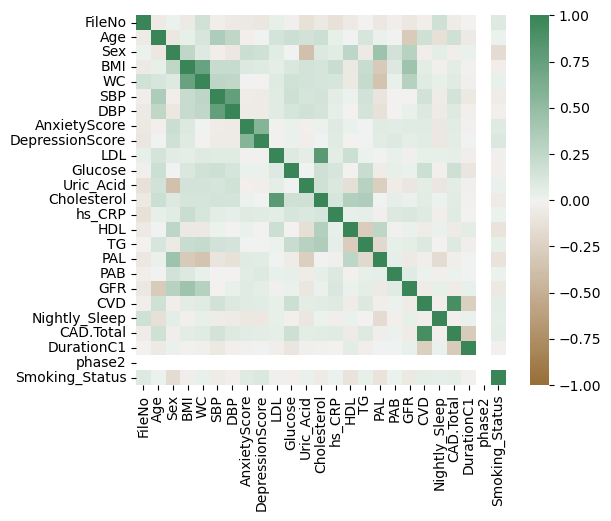

In [62]:
joined_for_heatmap=x_copy_normalization.join(y_copy_normalization)

correlation_full_health = joined_for_heatmap.corr()

axis_corr = sns.heatmap(
correlation_full_health,
vmin=-1, vmax=1, center=0,
cmap=sns.diverging_palette(50, 500, n=500),
square=True
)

plt.show() 

In [63]:
x_copy_feature_selection, y_copy_feature_selection, best_algo_feature_selection, best_accuracy_feature_selection,acc_holder_feature_selection=feature_selection(x_copy_normalization,y_copy_normalization)

SelectK

L1_Based

TreeBased

RFE_FeatureSelection

Chi2_Selection

VarianceThresh

7 Features named Index(['Sex', 'PAL', 'HDL', 'DepressionScore', 'GFR', 'Age', 'FileNo'], dtype='object') selected out of 23 


In [64]:
X_test=X_test[x_copy_feature_selection.columns]

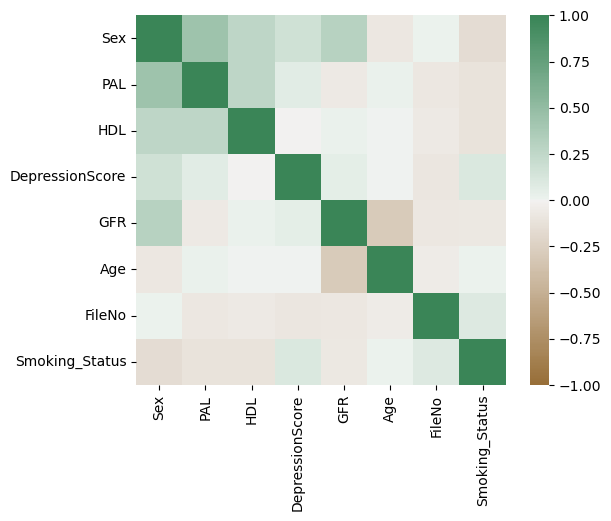

In [65]:
joined_for_heatmap=x_copy_feature_selection.join(y_copy_feature_selection)

correlation_full_health = joined_for_heatmap.corr()

axis_corr = sns.heatmap(
correlation_full_health,
vmin=-1, vmax=1, center=0,
cmap=sns.diverging_palette(50, 500, n=500),
square=True
)

plt.show() 

In [66]:
x_copy_feature_selection

,Sex,PAL,HDL,DepressionScore,GFR,Age,FileNo
0,1.0,0.832069,0.576085,0.248727,0.506267,0.500000,0.000000
1,0.0,0.767641,0.458894,0.746180,0.458652,0.833333,0.000106
2,1.0,0.609270,0.391928,0.547198,0.478263,0.285714,0.000159
3,1.0,0.997070,0.475636,0.870543,0.506267,0.166667,0.000212
4,1.0,0.750865,0.710018,0.223854,0.458652,0.666667,0.000265
...,...,...,...,...,...,...,...
7556,1.0,0.692659,0.914265,0.248727,0.506267,0.547619,0.999576
7557,1.0,0.653400,0.619613,0.024873,0.506267,0.238095,0.999735
7558,0.0,0.539277,0.579433,0.124363,0.506267,0.309524,0.999788
7559,1.0,0.616668,0.633006,0.696434,0.478263,0.619048,0.999894


In [67]:
model, best_algo_model_training, best_accuracy_model_training,acc_holder_model_training=model_training(x_copy_feature_selection,y_copy_feature_selection)

NeuralNetworkBased

Running NeuralNetworkBased with 6 model configurations...


/home/strix/Python/AI/miniconda3/envs/qenv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


NeuralNetworkBased custom score: 0.6708
SVMBased

Running SVMBased with 12 model configurations...


/home/strix/Python/AI/miniconda3/envs/qenv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


SVMBased custom score: 0.5971
RandomForestBased

Running RandomForestBased with 12 model configurations...
RandomForestBased custom score: 0.7928
XGBoostBased

Running XGBoostBased with 18 model configurations...


/home/strix/Python/AI/miniconda3/envs/qenv/lib/python3.12/site-packages/xgboost/core.py:158: UserWarning: [23:49:52] WARNING: /croot/xgboost-split_1724073744422/work/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/home/strix/Python/AI/miniconda3/envs/qenv/lib/python3.12/site-packages/xgboost/core.py:158: UserWarning: [23:49:52] WARNING: /croot/xgboost-split_1724073744422/work/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/home/strix/Python/AI/miniconda3/envs/qenv/lib/python3.12/site-packages/xgboost/core.py:158: UserWarning: [23:49:53] WARNING: /croot/xgboost-split_1724073744422/work/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/home/strix/Python/AI/miniconda3/envs/qenv/lib/python3.12/site-packages/xgboost/core.py:158: UserWarning: [23:49:53] WARNING: /croot/xgboost-split_1724073744422/work/src/learner.cc:

XGBoostBased custom score: 0.7984
Running XGBoostBased with 18 model configurations...


/home/strix/Python/AI/miniconda3/envs/qenv/lib/python3.12/site-packages/xgboost/core.py:158: UserWarning: [23:50:28] WARNING: /croot/xgboost-split_1724073744422/work/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/home/strix/Python/AI/miniconda3/envs/qenv/lib/python3.12/site-packages/xgboost/core.py:158: UserWarning: [23:50:28] WARNING: /croot/xgboost-split_1724073744422/work/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/home/strix/Python/AI/miniconda3/envs/qenv/lib/python3.12/site-packages/xgboost/core.py:158: UserWarning: [23:50:28] WARNING: /croot/xgboost-split_1724073744422/work/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/home/strix/Python/AI/miniconda3/envs/qenv/lib/python3.12/site-packages/xgboost/core.py:158: UserWarning: [23:50:29] WARNING: /croot/xgboost-split_1724073744422/work/src/learner.cc:

XGBoostBased custom score: 0.7984


In [68]:
model

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=None, num_parallel_tree=None, objective='multi:softprob', ...)

In [69]:
Y_test=model.predict(X_test)

In [74]:
Test=X_test.join(pd.DataFrame({"y_column":Y_test}))

In [75]:
Test

,Sex,PAL,HDL,DepressionScore,GFR,Age,FileNo,y_column
0,1.0,0.660755,0.275,0.166667,NaN,0.548387,0.000000,0
1,0.0,0.533454,0.100,0.833333,NaN,1.000000,0.086957,0
2,1.0,0.220538,0.000,0.566667,NaN,0.258065,0.130435,0
3,1.0,1.000000,0.125,1.000000,NaN,0.096774,0.173913,0
4,1.0,0.500307,0.475,0.133333,NaN,0.774194,0.217391,0
5,0.0,0.866596,0.725,1.000000,NaN,0.354839,0.260870,0
6,1.0,0.856356,0.750,0.500000,NaN,0.354839,0.347826,0
7,0.0,0.140106,0.750,0.966667,NaN,0.000000,0.434783,0
8,0.0,0.113471,0.250,0.400000,NaN,0.709677,0.478261,0
9,0.0,0.089964,0.325,0.066667,NaN,0.290323,0.521739,0


In [76]:
print(best_accuracy_model_training)

0.7983701160946378


In [73]:
all_algorithms=[best_algo_clean_data,best_algo_tame_outlier,best_algo_normalization,best_algo_feature_selection,best_algo_model_training]
print(*all_algorithms,sep="\n")

impute_class_mean
SP
MinMaxScalarNorm
SelectK
XGBoostBased
